In [3]:
# Notebook.ipynb  ── celda 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats

# ─── carga del Parquet ─────────────────────────────
PARQUET = "../data/features/features_202507.parquet"   # sube un nivel
# Si prefieres algo que funcione desde cualquier ruta:
# from pathlib import Path
# PARQUET = Path(__file__).resolve().parents[1] / "data" / "features_202507.parquet"

df = pd.read_parquet(PARQUET)
print("Shape:", df.shape)
df.tail()


Shape: (320054, 22)


,address,timestamp,discovered_via,age_minutes,liquidity_usd,volume_24h_usd,txns_last_5m,holders,rug_score,cluster_bad,...,price_pct_5m,volume_pct_5m,social_ok,twitter_followers,discord_members,score_total,trend,is_incomplete,label,ts
320049,3cLbnQ3pSr3vfZ498okLCHaKViMKALjn34BubRJxeDDD,2025-07-06 16:12:22.556770,dex,76.875946,21057.919922,135365.265625,0,0,0,0,...,0.0,0.0,0,0,0,60,0,0,0,2025-07-06 16:12:22.556770
320050,0x3AC4Af66dd7b2Ac79BCc51E9fA6eb9b0D1e335ff,2025-07-06 16:12:22.741944,dex,188.595703,183436.984375,846007.750000,0,0,0,0,...,0.0,0.0,0,0,0,60,0,0,0,2025-07-06 16:12:22.741944
320051,AgkwYP7VGcaeb93Aupb4Zy2i7ZyGHypncekBB5dd3JNa,2025-07-06 16:12:22.882323,dex,94.214706,0.000000,117765.343750,0,0,0,0,...,0.0,0.0,0,0,0,45,0,1,0,2025-07-06 16:12:22.882323
320052,5t5ZavnyifrzsSdYqXCoNWnZc1xAqPxKJzK4j3Y6vxWq,2025-07-06 16:12:23.022423,dex,317.183716,9600.469727,346852.562500,0,0,0,0,...,0.0,0.0,0,0,0,60,0,0,0,2025-07-06 16:12:23.022423
320053,EEPR293AeyXqFefgtrTiajexe63LSUs2Qn3tEthhEwK9,2025-07-06 16:12:23.198991,dex,354.519989,1476.319946,6262.080078,0,0,0,0,...,0.0,0.0,0,0,0,25,0,0,0,2025-07-06 16:12:23.198991


In [4]:
import pandas as pd
import io
from IPython.display import display  # ← funciona en Jupyter / VS Code

PARQUET = "../data/features/features_202507.parquet"   # ajusta si es necesario
df = pd.read_parquet(PARQUET)

# ── 1) Resumen df.info() ──────────────────────────────────
buf = io.StringIO()
df.info(buf=buf)
print(buf.getvalue())          # se imprime en la consola

# ── 2) % de nulos por columna ─────────────────────────────
null_pct = df.isna().mean().sort_values(ascending=False) * 100
top_nulls = (
    null_pct.head(15)
    .round(2)
    .to_frame(name="null_pct_%")
)

display(top_nulls)             # tabla bonita en notebook
# Si ejecutas como script (python archivo.py), usa:
# print(top_nulls.to_string())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320054 entries, 0 to 320053
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   address              320054 non-null  object        
 1   timestamp            320054 non-null  datetime64[us]
 2   discovered_via       320054 non-null  object        
 3   age_minutes          320054 non-null  float32       
 4   liquidity_usd        320054 non-null  float32       
 5   volume_24h_usd       320054 non-null  float32       
 6   txns_last_5m         320054 non-null  int32         
 7   holders              320054 non-null  int32         
 8   rug_score            320054 non-null  int32         
 9   cluster_bad          320054 non-null  int8          
 10  mint_auth_renounced  320054 non-null  int8          
 11  price_pct_1m         320054 non-null  float32       
 12  price_pct_5m         320054 non-null  float32       
 13  volume_pct_5m 

,null_pct_%
address,0.0
timestamp,0.0
discovered_via,0.0
age_minutes,0.0
liquidity_usd,0.0
volume_24h_usd,0.0
txns_last_5m,0.0
holders,0.0
rug_score,0.0
cluster_bad,0.0


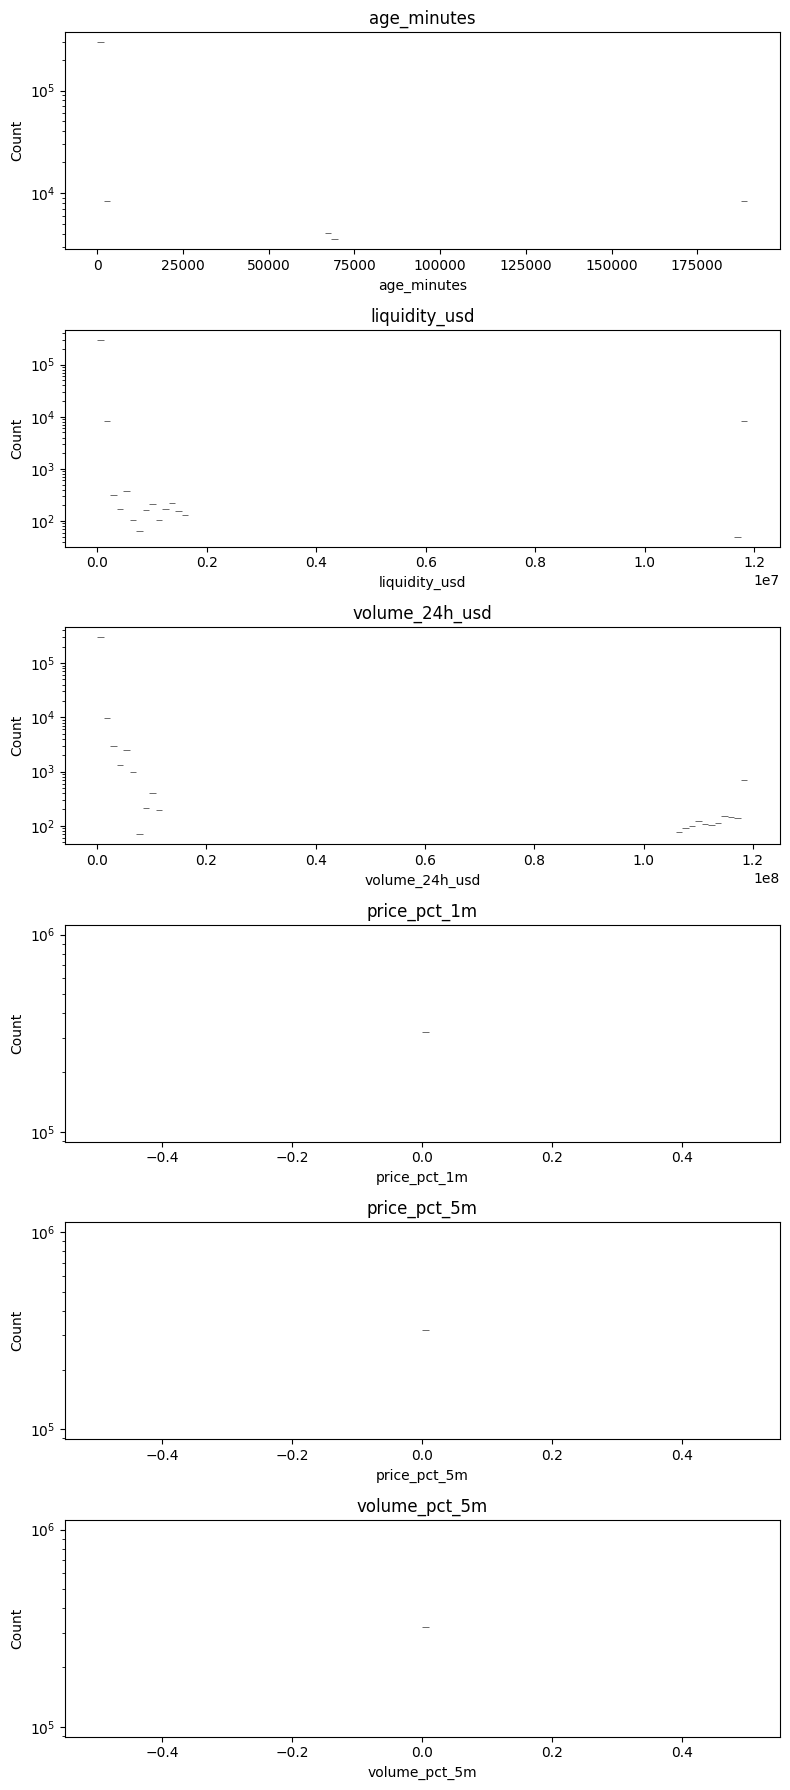

In [5]:
# Celda 3 ─ Distribuciones continuas (histogramas)
cont_vars = [
    "age_minutes", "liquidity_usd", "volume_24h_usd",
    "price_pct_1m", "price_pct_5m", "volume_pct_5m",
]

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(len(cont_vars), 1, figsize=(8, 3*len(cont_vars)))
for ax, col in zip(axes, cont_vars):
    sns.histplot(df[col], ax=ax, bins=100, log_scale=(False, True))
    ax.set_title(col)
plt.tight_layout()


In [6]:
# Celda 4 ─ Correlación numérica vs. label (robusta)
from scipy.stats import pointbiserialr

target = "label"
num_cols = cont_vars + ["rug_score", "holders", "twitter_followers"]

corrs = []
for col in num_cols:
    # saltamos columnas sin variabilidad
    if df[col].nunique(dropna=False) <= 1:
        continue
    # aseguramos tipo float (necesario si hay int8/32)
    series = df[col].astype(float)
    r, p = pointbiserialr(df[target], series)
    corrs.append((col, r, p))

corr_df = (
    pd.DataFrame(corrs, columns=["feature", "r_pb", "p_value"])
    .assign(abs_r=lambda d: d["r_pb"].abs())
    .sort_values("abs_r", ascending=False)
    .drop(columns="abs_r")
)

display(corr_df.head(10))


,feature,r_pb,p_value
0,age_minutes,-0.067179,9.245781e-317
2,volume_24h_usd,-0.023002,1.010501e-38
1,liquidity_usd,-0.020068,7.052802e-30


In [7]:
# Celda 5 ─ Crosstabs categóricas
cat_cols = ["cluster_bad", "mint_auth_renounced", "social_ok", "trend"]

for col in cat_cols:
    ctab = pd.crosstab(df[col], df[target], normalize="index") * 100
    display(ctab.style.format("{:.1f}%").set_caption(col))


label,0,1
cluster_bad,,
0,91.3%,8.7%


label,0,1
mint_auth_renounced,,
0,91.3%,8.7%


label,0,1
social_ok,,
0,91.3%,8.7%


label,0,1
trend,,
0,91.3%,8.7%


In [8]:
# Celda 6 ─ Positivos vs. negativos
pos, neg = df["label"].value_counts().sort_index()
print(f"Positivos: {pos} • Negativos: {neg} • Pos/Neg = {pos/neg:.3f}")


Positivos: 292116 • Negativos: 27938 • Pos/Neg = 10.456


In [9]:
# Celda 7 ─ Benchmark logístico
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

use_cols = [c for c in df.columns if c not in ("label", "address", "timestamp", "ts", "discovered_via")]
X = df[use_cols].astype(float)   # aseguramos numérico
y = df["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

lr = LogisticRegression(max_iter=200, class_weight="balanced")
lr.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, lr.predict_proba(X_te)[:, 1])
print(f"Logistic AUC = {auc:.4f}")


Logistic AUC = 0.9172


,gain
liquidity_usd,74469.067497
age_minutes,60160.600488
volume_24h_usd,28667.261354
score_total,22539.067327
txns_last_5m,0.000000
rug_score,0.000000
cluster_bad,0.000000
mint_auth_renounced,0.000000
holders,0.000000
price_pct_1m,0.000000


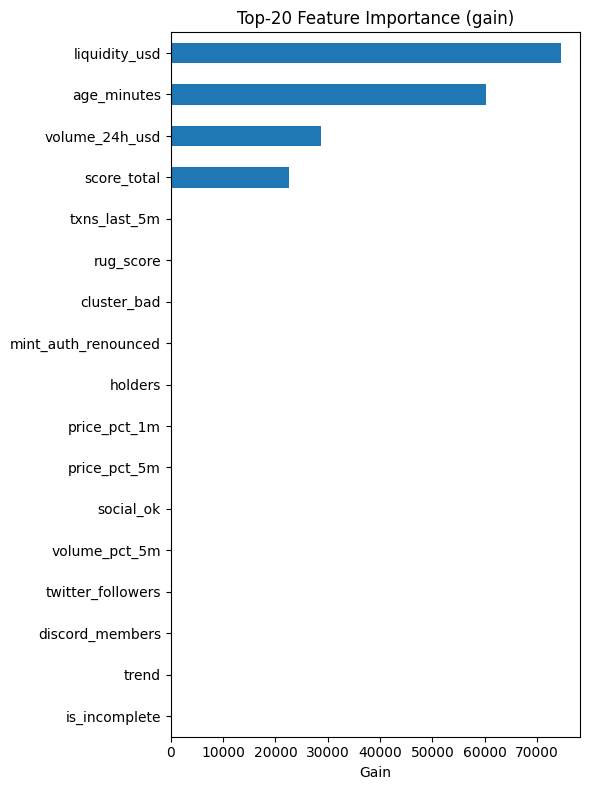

In [10]:
# Celda 8 ─ Feature importance LightGBM (versión Booster)
import joblib, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

model = joblib.load(Path("../ml/model.pkl"))      # Booster

names = model.feature_name()                      # lista[str]
gain  = model.feature_importance(importance_type="gain")  # array[np.float]

imp_df = (
    pd.Series(gain, index=names, name="gain")
      .sort_values(ascending=False)
      .head(20)
)

display(imp_df.to_frame())                        # tabla

# gráfico
imp_df[::-1].plot(kind="barh", figsize=(6,8))
plt.title("Top-20 Feature Importance (gain)")
plt.xlabel("Gain")
plt.tight_layout()
plt.show()


,count
label,
0,292116
1,27938



Proporción positiva: 8.73%


C:\Users\monmo10\AppData\Local\Temp\ipykernel_27288\3351604364.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


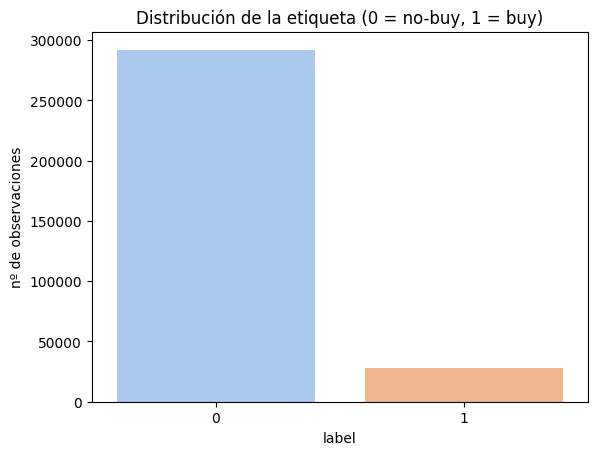

In [ ]:
# Celda X – Distribución de la etiqueta
import matplotlib.pyplot as plt
import seaborn as sns

label_counts = df["label"].value_counts(dropna=False).sort_index()
display(label_counts.to_frame("count"))

pos_ratio = label_counts.get(1, 0) / label_counts.sum()
print(f"\nProporción positiva: {pos_ratio:.2%}")

# ─── gráfico opcional ──────────────────────────────────────
ax = sns.barplot(
    x=label_counts.index.astype(str),
    y=label_counts.values,
    palette="pastel"
)
ax.set_title("Distribución de la etiqueta (0 = no-buy, 1 = buy)")
ax.set_xlabel("label")
ax.set_ylabel("nº de observaciones")
plt.show()
